# Mixed-slice UEs moving slowly from gNB0 toward gNB1

This scenario follows five eMBB, three URLLC, and four mMTC UEs along a slow straight path from gNB0 toward gNB1 while every UE remains inside the coverage of all three gNBs. A scenario heuristic makes gNB0 release each overloaded slice; gNB1 and gNB2 retain admitted UEs. The directional local heuristic selects slice-specific A3 offsets, and the deterministic safe-admission layer limits migration.

The notebook runs the same trajectory twice: with safe admission and without it.

### Notebook map

1. Import the simulator and define experiment constants.
2. Build the three-gNB environment and the heuristic upper/local controllers.
3. Execute the safe and unsafe mobility experiments and collect traces.
4. Plot the geometry before motion, after motion, and across the complete path.
5. Plot before/after loads, serving populations, biases, offsets, and admission decisions.
6. Run assertions that verify coverage and safe-layer behavior.

In [1]:
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
from IPython.display import display

from global_ppo_3gnb_env import DEFAULT_GNB_CONFIGS_3, SLICE_TYPES
from scenario_creator import create_multignb_env
from strong_heuristic_local_executor import strong_directional_heuristic_local_executor

plt.style.use('seaborn-v0_8-whitegrid')
NEIGHBORS = {0: [1, 2], 1: [0, 2], 2: [0, 1]}
SLICE_INDEX = {name: idx for idx, name in enumerate(SLICE_TYPES)}
SAFE_LIMIT = 0.80
N_WINDOWS = 51
MOBILITY_DT_S = 1.0
SPEED_MPS = 5.0
SLICE_PROFILES = {
    'eMBB': {'count': 5, 'prbs_per_ue': 18, 'marker': 'o'},
    'URLLC': {'count': 3, 'prbs_per_ue': 25, 'marker': 's'},
    'mMTC': {'count': 4, 'prbs_per_ue': 15, 'marker': 'D'},
}
print('Trajectory duration:', (N_WINDOWS - 1) * MOBILITY_DT_S, 'seconds')


Trajectory duration: 50.0 seconds


## Scenario and controller helpers

The previous cell imports the required packages and defines the shared constants: 51 control windows, one second of movement per window, 5 m/s UE speed, and a hard receiving-load limit of 0.80.

The cell below defines the experiment machinery:

- `force_attach` places a UE on a selected serving cell.
- `build_env` creates three overlapping gNBs and moving UEs from all three slices.
- `load_matrix` reads the per-gNB/per-slice PRB load.
- `heuristic_upper_bias` makes only the original source gNB release traffic.
- `directional_offsets` mimics the local agent and selects one offset per neighbor and slice.
- `apply_offsets` installs those decisions in the simulator.

All UEs start near `(100, 60)` and move at 5 m/s toward gNB1. Small y offsets separate the traces without changing the overlap geometry. The initial gNB0 load vector is `[0.90, 0.75, 0.60]` for `[eMBB, URLLC, mMTC]`.

### Implement the scenario helpers

The following code cell implements the helper functions described above. Running it defines the environment builder, upper heuristic, directional local executor bridge, and offset application functions; it does not start the experiment yet.

In [2]:
def force_attach(env, ue_id, gnb_id):
    ue = env.get_ue(ue_id)
    for gnb in env.gnbs:
        gnb.detach_ue(ue_id)
    target = env._get_gnb_by_id(gnb_id)
    assert target.attach_ue(ue)
    ue.serving_gnb = int(gnb_id)
    ue.connected = True
    env._last_serving_gnb[ue_id] = int(gnb_id)


def build_env(safe_enabled):
    env = create_multignb_env(
        rng=np.random.default_rng(19),
        n=4,
        gnb_configs=DEFAULT_GNB_CONFIGS_3,
        slots_per_step=1,
        L1_level=False,
        step_dt=1e-3,
        mobility_dt=MOBILITY_DT_S,
        radio_substeps=1,
        max_episode_steps=N_WINDOWS + 5,
        handover_ttt=2,
        a3_handover_cooldown_s=10.0,
        a3_min_residence_s=20.0,
        safe_admission_enabled=safe_enabled,
        safe_admission_load_limits={s: SAFE_LIMIT for s in SLICE_TYPES},
    )
    env.clear_ues(reset_ids=True)
    total_ues = sum(profile['count'] for profile in SLICE_PROFILES.values())
    y_positions = iter(np.linspace(48.0, 72.0, total_ues))
    for slice_type, profile in SLICE_PROFILES.items():
        for _ in range(profile['count']):
            ue_id = env.add_ue(
                x=100.0,
                y=float(next(y_positions)),
                vx=SPEED_MPS,
                vy=0.0,
                slice_type=slice_type,
            )
            force_attach(env, ue_id, 0)
            ue = env.get_ue(ue_id)
            ue.prbs = profile['prbs_per_ue']
            ue.useful_prbs = profile['prbs_per_ue']
            ue.wasted_prbs = 0
    env._invalidate_metric_caches()
    return env


def load_matrix(env):
    loads = env.get_slice_loads()
    return np.asarray([
        [loads.get((g, s), 0.0) for s in SLICE_TYPES]
        for g in range(3)
    ], dtype=float)


def heuristic_upper_bias(loads, deadband=0.05):
    means = loads.mean(axis=0)
    bias = np.zeros_like(loads)
    # Scenario policy: only the original source gNB releases traffic.
    for s_idx in range(len(SLICE_TYPES)):
        if loads[0, s_idx] > means[s_idx] + deadband:
            bias[0, s_idx] = -0.8
        bias[1, s_idx] = +0.4
        bias[2, s_idx] = +0.4
    return bias


def mobility_ratio_tensor(env, ratios):
    tensor = np.zeros((3, 2, 3), dtype=float)
    for source, neighbors in NEIGHBORS.items():
        for slot, target in enumerate(neighbors):
            for s_idx, slice_type in enumerate(SLICE_TYPES):
                tensor[source, slot, s_idx] = ratios.get(
                    (source, target, slice_type.upper()), 0.0
                )
    return tensor


def directional_offsets(env, bias, previous):
    ues = sorted(env.get_all_ues(), key=lambda ue: ue.id)
    ue_slice = np.asarray([SLICE_INDEX[ue.slice_type] for ue in ues], dtype=int)
    serving = np.asarray([ue.serving_gnb for ue in ues], dtype=int)
    rsrp = np.asarray([
        [env._measure_rsrp(env._get_gnb_by_id(g), ue) for g in range(3)]
        for ue in ues
    ], dtype=float)
    return strong_directional_heuristic_local_executor(
        B=bias,
        prev_offsets=previous,
        ue_slice=ue_slice,
        ue_serving_gnb=serving,
        rsrp_matrix=rsrp,
        neighbor_graph=NEIGHBORS,
        load=load_matrix(env),
        sla_violation=np.zeros((3, 3), dtype=float),
        ho_failure_ratio=mobility_ratio_tensor(env, env.get_handover_failure_ratios()),
        pingpong_ratio=mobility_ratio_tensor(env, env.get_ping_pong_ratios()),
        hysteresis_db=env.a3_hysteresis_db,
        l_safe=SAFE_LIMIT,
        allow_extended_negative_offsets=True,
    )


def apply_offsets(env, offsets):
    for source, neighbors in NEIGHBORS.items():
        for slot, target in enumerate(neighbors):
            for s_idx, slice_type in enumerate(SLICE_TYPES):
                env.set_a3_offset(source, target, slice_type, offsets[source, slot, s_idx])


## Run the mobility experiment

This cell advances the scenario one control window at a time. At every window it measures load, computes the heuristic upper bias, calculates directional A3 offsets, opens a new admission window, evaluates handovers, and records UE radio/serving state.

It executes two identical seeded cases:

- **Safe admission:** eligible handovers are limited by bias pressure, source excess, target headroom, and the hard load limit.
- **Unsafe baseline:** the same radio and offset decisions execute without the admission filter.

In [3]:
def run_mobility_case(safe_enabled):
    env = build_env(safe_enabled)
    previous_offsets = np.zeros((3, 2, 3), dtype=float)
    rows, ue_rows, event_rows = [], [], []

    for window in range(N_WINDOWS):
        env._step_count = window
        before_events = len(env.handover_events)
        loads_before = load_matrix(env)
        bias = heuristic_upper_bias(loads_before)
        offsets = directional_offsets(env, bias, previous_offsets)
        apply_offsets(env, offsets)
        capacities = env.begin_safe_admission_window(bias, SLICE_TYPES)
        handovers = env._evaluate_a3_handovers()
        loads_after = load_matrix(env)
        admission = env.get_safe_admission_state()

        new_events = env.handover_events[before_events:]
        for event in new_events:
            event_rows.append({'window': window, 'time_s': window * MOBILITY_DT_S, **event})

        serving_counts = [
            sum(int(ue.serving_gnb) == g for ue in env.get_all_ues())
            for g in range(3)
        ]
        row = {
            'window': window,
            'time_s': window * MOBILITY_DT_S,
            'handovers': handovers,
            'eligible': admission['stats']['eligible'],
            'accepted': admission['stats']['accepted'],
            'rejected_capacity': admission['stats']['rejected_capacity'],
        }
        for g in range(3):
            row[f'count_g{g}'] = serving_counts[g]
            for s_idx, slice_type in enumerate(SLICE_TYPES):
                row[f'load_g{g}_{slice_type}'] = loads_after[g, s_idx]
                row[f'bias_g{g}_{slice_type}'] = bias[g, s_idx]
                row[f'count_g{g}_{slice_type}'] = sum(
                    int(ue.serving_gnb) == g and ue.slice_type == slice_type
                    for ue in env.get_all_ues()
                )
        for source, neighbors in NEIGHBORS.items():
            for slot, target in enumerate(neighbors):
                for s_idx, slice_type in enumerate(SLICE_TYPES):
                    row[f'offset_{source}_{target}_{slice_type}'] = offsets[source, slot, s_idx]
                    key = (source, target, slice_type.upper())
                    row[f'capacity_{source}_{target}_{slice_type}'] = capacities[key]
                    row[f'admitted_{source}_{target}_{slice_type}'] = admission['accepted'][key]
        rows.append(row)

        for ue in sorted(env.get_all_ues(), key=lambda item: item.id):
            rsrp = [env._measure_rsrp(env._get_gnb_by_id(g), ue) for g in range(3)]
            coverage = [env._is_in_coverage(env._get_gnb_by_id(g), ue) for g in range(3)]
            ue_rows.append({
                'window': window,
                'time_s': window * MOBILITY_DT_S,
                'ue_id': ue.id,
                'x': ue.x,
                'y': ue.y,
                'slice_type': ue.slice_type,
                'serving_gnb': ue.serving_gnb,
                **{f'rsrp_g{g}': rsrp[g] for g in range(3)},
                **{f'covered_g{g}': coverage[g] for g in range(3)},
            })

        previous_offsets = offsets.copy()
        if window < N_WINDOWS - 1:
            for ue in env.get_all_ues():
                ue.update_position(MOBILITY_DT_S)
            env._invalidate_metric_caches()

    result = {
        'trace': pd.DataFrame(rows),
        'ues': pd.DataFrame(ue_rows),
        'events': pd.DataFrame(event_rows),
        'gnbs': pd.DataFrame([
            {'gnb': int(g.id), 'x': g.x, 'y': g.y, 'coverage_radius': g.coverage_radius}
            for g in env.gnbs
        ]),
    }
    env.close()
    return result


safe = run_mobility_case(True)
unsafe = run_mobility_case(False)

summary = pd.DataFrame([
    {
        'case': name,
        'total handovers': len(result['events']),
        'final serving counts': tuple(result['trace'].iloc[-1][[f'count_g{g}' for g in range(3)]].astype(int)),
        'maximum load': result['trace'][[
            f'load_g{g}_{s}' for g in range(3) for s in SLICE_TYPES
        ]].to_numpy().max(),
        'receiving-cell limit violations': int((result['trace'][[
            f'load_g{g}_{s}' for g in (1, 2) for s in SLICE_TYPES
        ]] > SAFE_LIMIT).sum().sum()),
    }
    for name, result in [('safe admission', safe), ('unsafe baseline', unsafe)]
])
summary


,case,total handovers,final serving counts,maximum load,receiving-cell limit violations
0,safe admission,9,"(3, 5, 4)",0.9,0
1,unsafe baseline,12,"(0, 12, 0)",0.9,40


## Geometry before, after, and during movement

The next cell produces three geometric views. Marker shape identifies the slice: circles are eMBB, squares are URLLC, and diamonds are mMTC. The **before** panel confirms that every UE begins on gNB0 inside the common three-cell overlap. The **after** panel shows final positions and serving cells. The **complete trajectory** panel marks every safe handover location with a red cross.

A separate RSRP plot underneath explains the changing radio preference: gNB0 begins strongest, gNB1 becomes strongest as the UEs move right, and gNB2 remains available throughout.

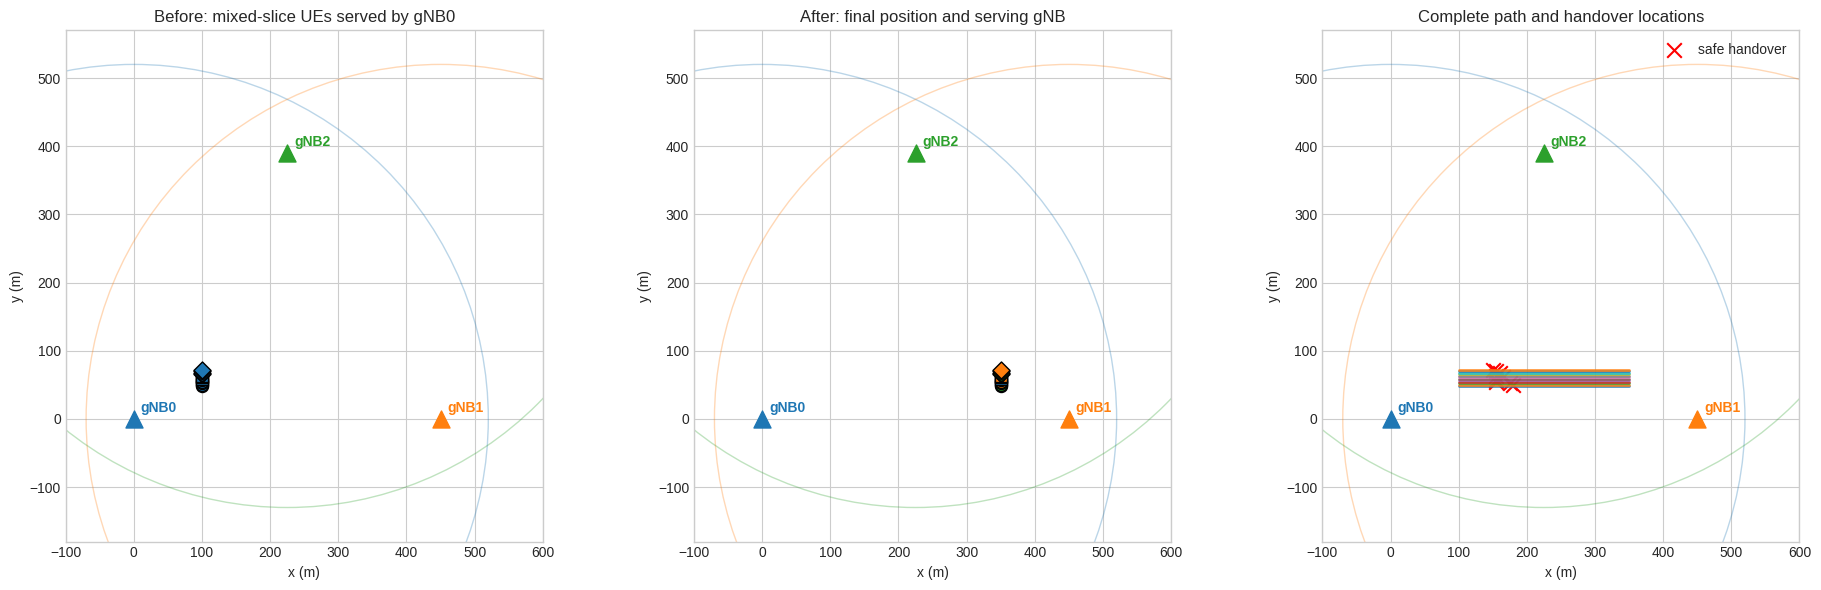

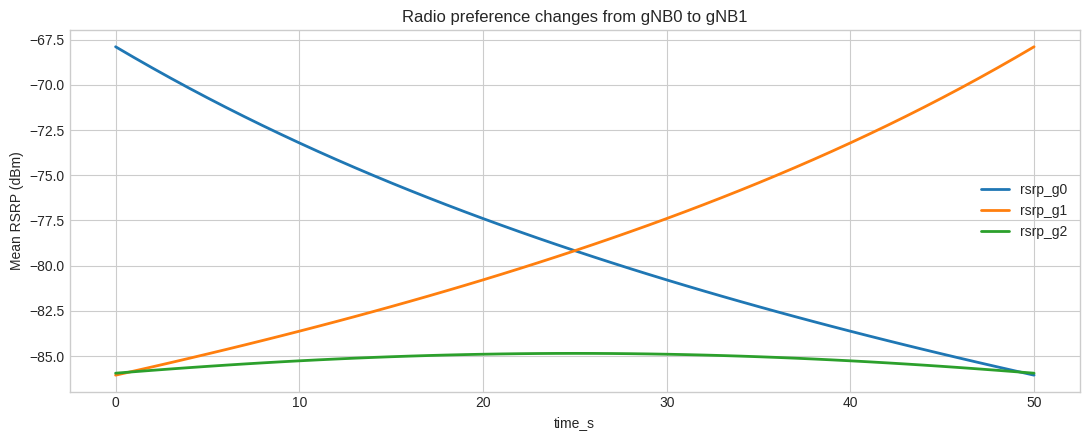

In [4]:
colors = ['tab:blue', 'tab:orange', 'tab:green']
serving_colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green'}
slice_markers = {name: profile['marker'] for name, profile in SLICE_PROFILES.items()}

def draw_network(ax):
    for row in safe['gnbs'].itertuples():
        ax.add_patch(Circle(
            (row.x, row.y), row.coverage_radius,
            fill=False, color=colors[row.gnb], alpha=0.30,
        ))
        ax.scatter(row.x, row.y, marker='^', s=150, color=colors[row.gnb])
        ax.text(row.x + 10, row.y + 10, f'gNB{row.gnb}', color=colors[row.gnb], weight='bold')
    ax.set_aspect('equal')
    ax.set_xlim(-100, 600)
    ax.set_ylim(-180, 570)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')

initial = safe['ues'][safe['ues'].window == safe['ues'].window.min()]
final = safe['ues'][safe['ues'].window == safe['ues'].window.max()]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax in axes:
    draw_network(ax)

for row in initial.itertuples():
    axes[0].scatter(row.x, row.y, marker=slice_markers[row.slice_type], s=75, color=serving_colors[row.serving_gnb], edgecolor='black')
axes[0].set_title('Before: mixed-slice UEs served by gNB0')

for row in final.itertuples():
    axes[1].scatter(row.x, row.y, marker=slice_markers[row.slice_type], s=75, color=serving_colors[row.serving_gnb], edgecolor='black')
axes[1].set_title('After: final position and serving gNB')

for ue_id, group in safe['ues'].groupby('ue_id'):
    axes[2].plot(group.x, group.y, linewidth=2, alpha=0.8)
if not safe['events'].empty:
    event_positions = safe['events'].merge(safe['ues'], on=['window', 'ue_id'])
    axes[2].scatter(event_positions.x, event_positions.y, marker='x', s=110, color='red', label='safe handover')
axes[2].set_title('Complete path and handover locations')
axes[2].legend()

plt.tight_layout()
plt.show()

mean_radio = safe['ues'].groupby('time_s')[[f'rsrp_g{g}' for g in range(3)]].mean()
mean_radio.plot(figsize=(11, 4.5), linewidth=2)
plt.ylabel('Mean RSRP (dBm)')
plt.title('Radio preference changes from gNB0 to gNB1')
plt.tight_layout()
plt.show()


## Serving cells, loads, and controller decisions

This four-panel figure explains the control sequence over time:

- Top-left: how the five UEs are distributed among serving gNBs.
- Top-right: how all three slice loads move away from gNB0 while receiving cells stay below the red safety line.
- Bottom-left: the heuristic upper bias from gNB0 for each slice.
- Bottom-right: neighbor-specific A3 offsets from gNB0 for each slice.

### Plot the controller timeline

The following cell creates the four time-series panels described above: serving-cell population, load redistribution, upper bias, and directional offsets.

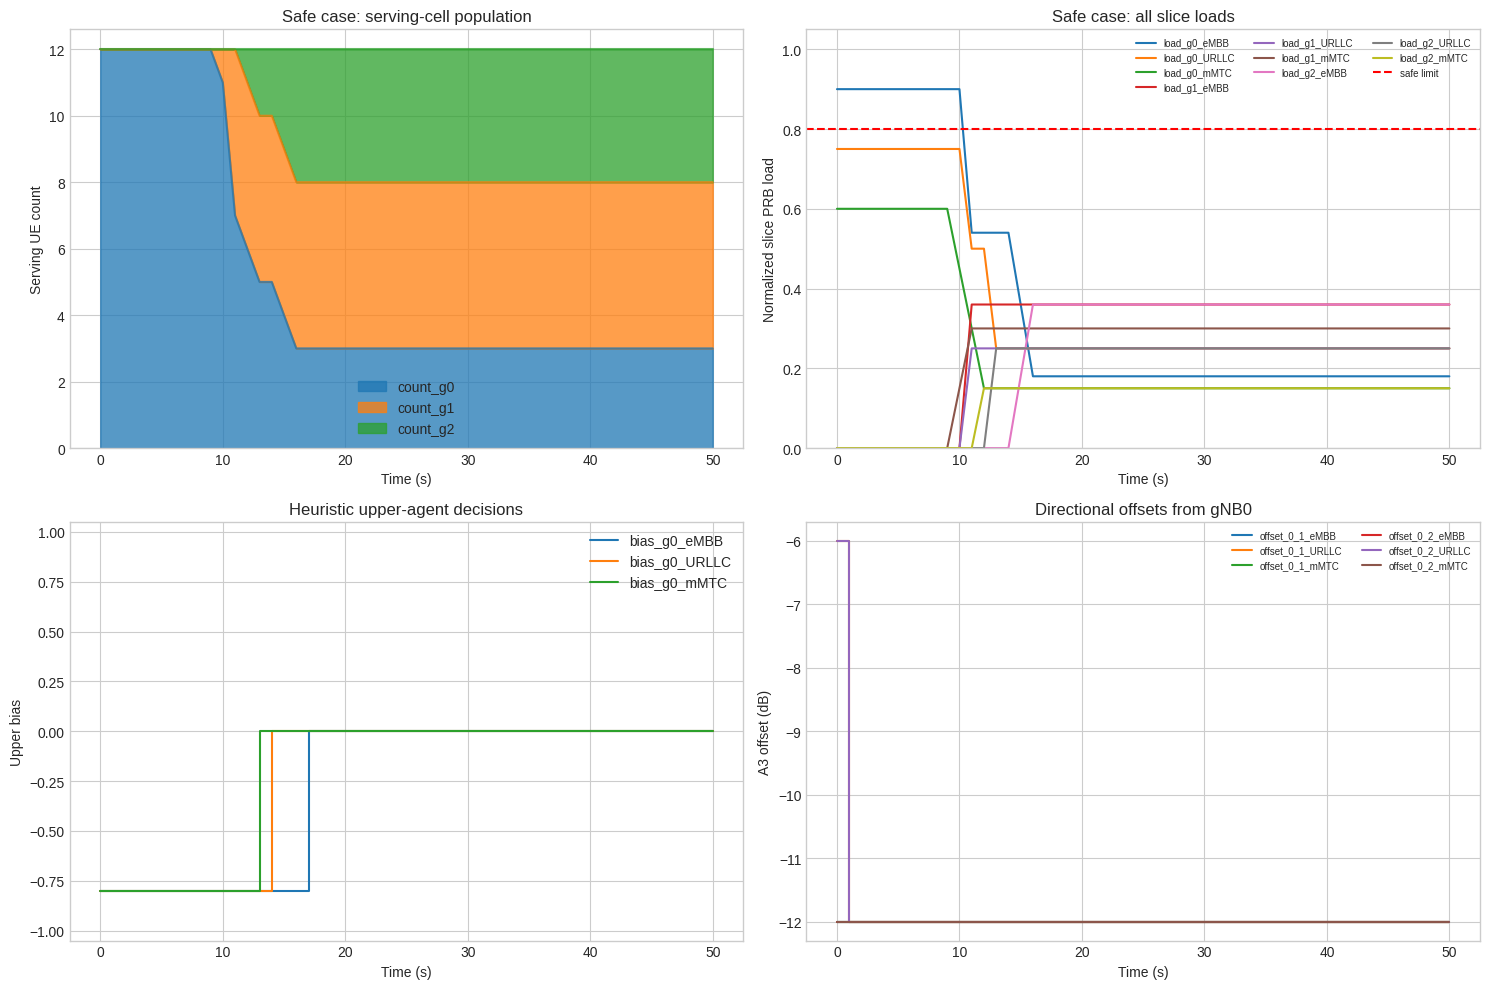

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

safe['trace'].plot(x='time_s', y=[f'count_g{g}' for g in range(3)], kind='area', stacked=True, ax=axes[0,0], alpha=0.75)
axes[0,0].set_ylabel('Serving UE count')
axes[0,0].set_title('Safe case: serving-cell population')

safe['trace'].plot(
    x='time_s',
    y=[f'load_g{g}_{s}' for g in range(3) for s in SLICE_TYPES],
    ax=axes[0,1], linewidth=1.5,
)
axes[0,1].axhline(SAFE_LIMIT, color='red', linestyle='--', label='safe limit')
axes[0,1].set_ylim(0, 1.05)
axes[0,1].set_ylabel('Normalized slice PRB load')
axes[0,1].set_title('Safe case: all slice loads')
axes[0,1].legend(fontsize=7, ncol=3)

safe['trace'].plot(x='time_s', y=[f'bias_g0_{s}' for s in SLICE_TYPES], ax=axes[1,0], drawstyle='steps-post')
axes[1,0].set_ylim(-1.05, 1.05)
axes[1,0].set_ylabel('Upper bias')
axes[1,0].set_title('Heuristic upper-agent decisions')

safe['trace'].plot(
    x='time_s',
    y=[f'offset_0_{target}_{s}' for target in (1, 2) for s in SLICE_TYPES],
    ax=axes[1,1], drawstyle='steps-post',
)
axes[1,1].legend(fontsize=7, ncol=2)
axes[1,1].set_ylabel('A3 offset (dB)')
axes[1,1].set_title('Directional offsets from gNB0')

for ax in axes.flat:
    ax.set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


## Explicit load before/after comparison and admission outcomes

The next cell first compares initial and final eMBB loads directly as a compact example. The matrix plots in the following section then show all three slices together. In the safe case, migration is divided between gNB1 and gNB2. In the unsafe case, UEs can collapse onto gNB1.

The remaining plots show how many candidates were eligible, accepted, or rejected by capacity in each window, and compare load variance between safe and unsafe execution.

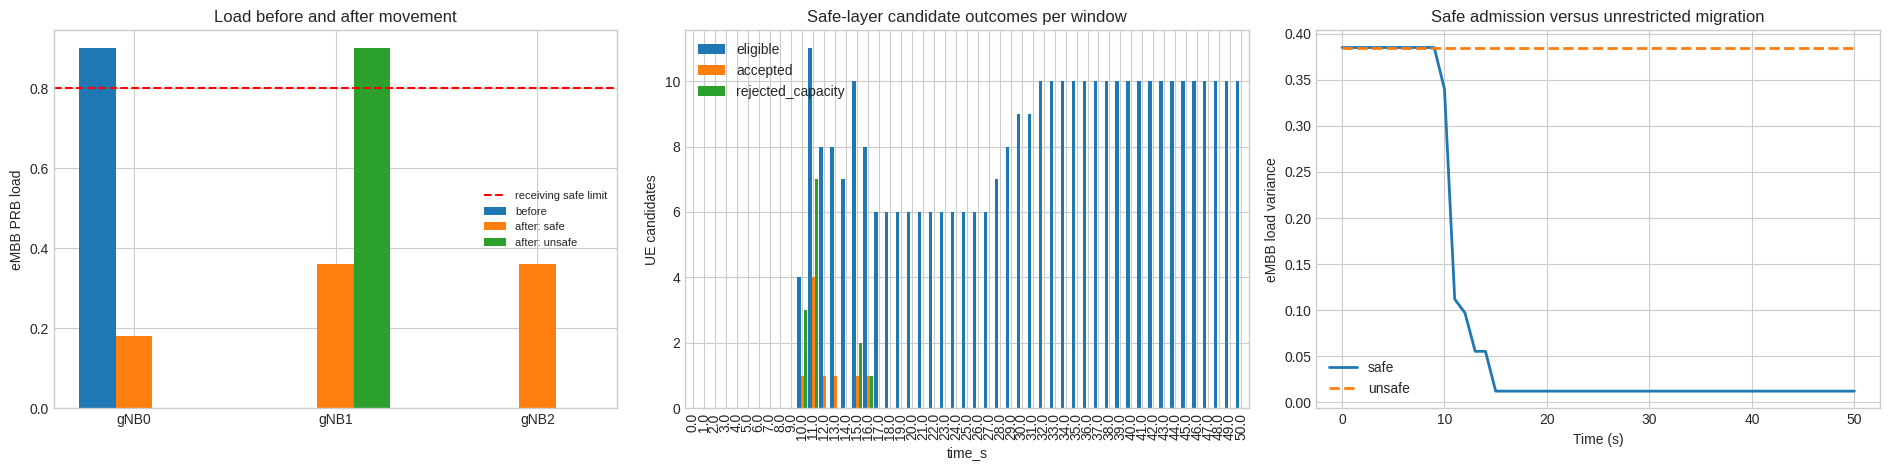

,case,total handovers,final serving counts,maximum load,receiving-cell limit violations
0,safe admission,9,"(3, 5, 4)",0.9,0
1,unsafe baseline,12,"(0, 12, 0)",0.9,40


,window,time_s,ue_id,slice_type,from_gnb,to_gnb,rsrp_serving_dbm,rsrp_target_dbm,offset_db
0,10,10.0,11,MMTC,0,1,-73.674663,-83.757763,-12.0
1,11,11.0,10,MMTC,0,1,-74.025521,-83.471055,-12.0
2,11,11.0,7,URLLC,0,1,-73.775620,-83.393290,-12.0
3,11,11.0,4,EMBB,0,1,-73.543549,-83.322534,-12.0
4,11,11.0,3,EMBB,0,1,-73.470462,-83.300539,-12.0
5,12,12.0,9,MMTC,0,2,-74.378043,-84.799955,-12.0
6,13,13.0,6,URLLC,0,2,-74.587054,-85.070093,-12.0
7,15,15.0,2,EMBB,0,2,-75.199111,-85.407570,-12.0
8,16,16.0,1,EMBB,0,2,-75.570139,-85.477570,-12.0


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))

x = np.arange(3)
width = 0.18
safe_before = safe['trace'].iloc[0][[f'load_g{g}_eMBB' for g in range(3)]].to_numpy(dtype=float)
safe_after = safe['trace'].iloc[-1][[f'load_g{g}_eMBB' for g in range(3)]].to_numpy(dtype=float)
unsafe_after = unsafe['trace'].iloc[-1][[f'load_g{g}_eMBB' for g in range(3)]].to_numpy(dtype=float)
axes[0].bar(x - width, safe_before, width, label='before')
axes[0].bar(x, safe_after, width, label='after: safe')
axes[0].bar(x + width, unsafe_after, width, label='after: unsafe')
axes[0].axhline(SAFE_LIMIT, color='red', linestyle='--', label='receiving safe limit')
axes[0].set_xticks(x, ['gNB0', 'gNB1', 'gNB2'])
axes[0].set_ylabel('eMBB PRB load')
axes[0].set_title('Load before and after movement')
axes[0].legend(fontsize=8)

decision_cols = ['eligible', 'accepted', 'rejected_capacity']
safe['trace'].plot(x='time_s', y=decision_cols, kind='bar', ax=axes[1], width=0.9)
axes[1].set_title('Safe-layer candidate outcomes per window')
axes[1].set_ylabel('UE candidates')
axes[1].tick_params(axis='x', labelrotation=90)

for result, label, style in ((safe, 'safe', '-'), (unsafe, 'unsafe', '--')):
    load_values = result['trace'][[
        f'load_g{g}_{s}' for g in range(3) for s in SLICE_TYPES
    ]].to_numpy(dtype=float).reshape(-1, 3, 3)
    variance = np.var(load_values, axis=1).sum(axis=1)
    axes[2].plot(result['trace'].time_s, variance, style, linewidth=2, label=label)
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('eMBB load variance')
axes[2].set_title('Safe admission versus unrestricted migration')
axes[2].legend()

plt.tight_layout()
plt.show()

display(summary)
display(safe['events'][['window', 'time_s', 'ue_id', 'slice_type', 'from_gnb', 'to_gnb', 'rsrp_serving_dbm', 'rsrp_target_dbm', 'offset_db']])


## Load matrix, bias matrix, and directional offset matrix

These heatmaps expose the complete v15 control state at three moments: before any handover, at the first safe-handover window, and at the end.

- **Load matrix:** rows are gNBs and columns are slices.
- **Bias matrix:** rows are gNBs and columns are slices; negative means release and positive means retain.
- **Offset matrix:** rows are directed links and columns are slices; more-negative values make A3 eligibility easier in that direction.

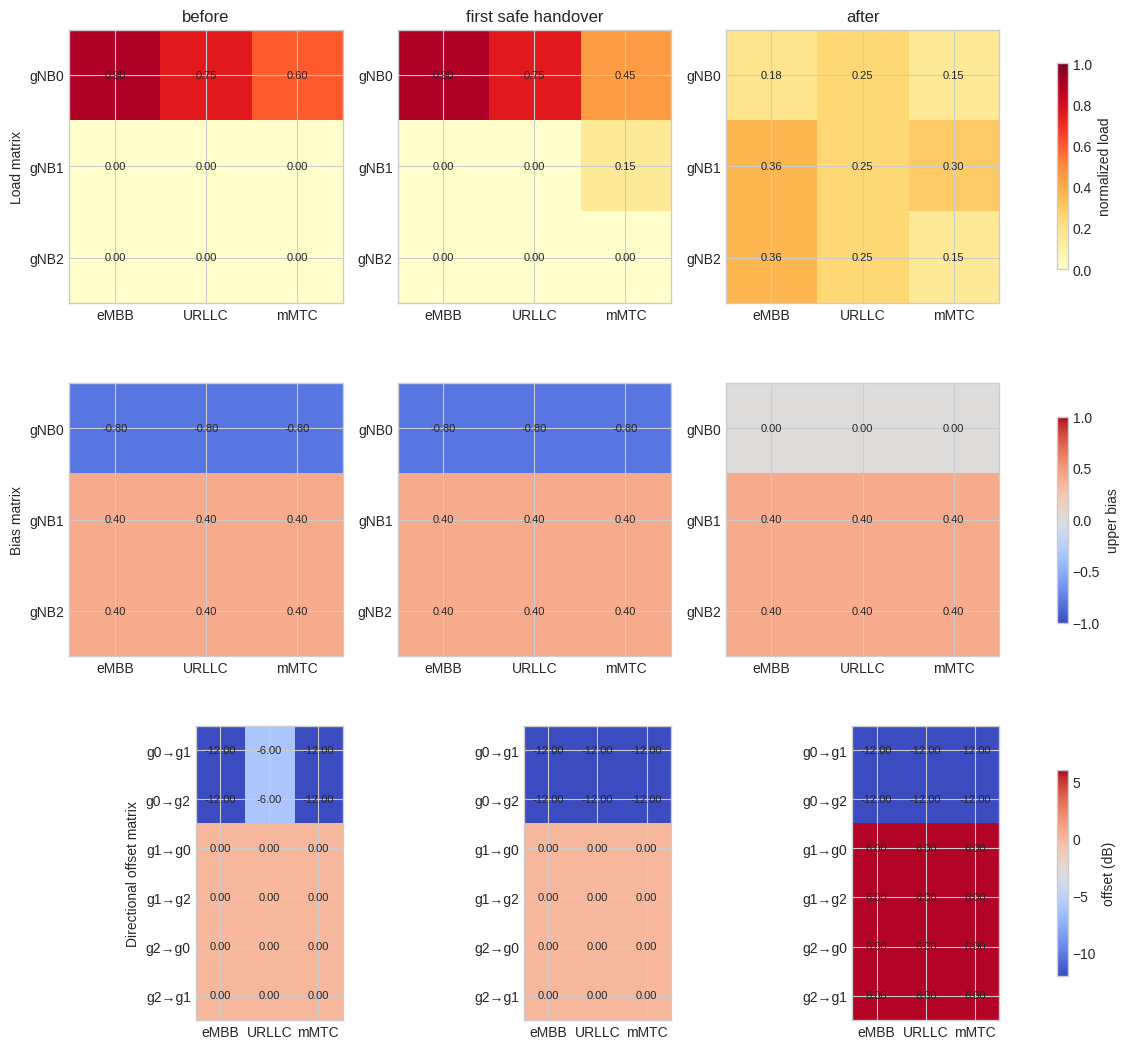

In [7]:
def matrix_from_trace(row, prefix):
    return np.asarray([
        [row[f'{prefix}_g{g}_{slice_type}'] for slice_type in SLICE_TYPES]
        for g in range(3)
    ], dtype=float)


def offset_matrix_from_trace(row):
    directions = [(source, target) for source, targets in NEIGHBORS.items() for target in targets]
    matrix = np.asarray([
        [row[f'offset_{source}_{target}_{slice_type}'] for slice_type in SLICE_TYPES]
        for source, target in directions
    ], dtype=float)
    labels = [f'g{source}→g{target}' for source, target in directions]
    return matrix, labels


first_handover_window = int(safe['events'].window.min())
snapshot_windows = [0, first_handover_window, N_WINDOWS - 1]
snapshot_titles = ['before', 'first safe handover', 'after']

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
for col, (window, title) in enumerate(zip(snapshot_windows, snapshot_titles)):
    row = safe['trace'].loc[safe['trace'].window == window].iloc[0]
    load = matrix_from_trace(row, 'load')
    bias = matrix_from_trace(row, 'bias')
    offsets, direction_labels = offset_matrix_from_trace(row)

    images = [
        axes[0, col].imshow(load, vmin=0, vmax=1, cmap='YlOrRd'),
        axes[1, col].imshow(bias, vmin=-1, vmax=1, cmap='coolwarm'),
        axes[2, col].imshow(offsets, vmin=-12, vmax=6, cmap='coolwarm'),
    ]
    matrices = [load, bias, offsets]
    for row_idx, matrix in enumerate(matrices):
        axes[row_idx, col].set_xticks(range(3), SLICE_TYPES)
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                axes[row_idx, col].text(j, i, f'{matrix[i,j]:.2f}', ha='center', va='center', fontsize=8)
    axes[0, col].set_yticks(range(3), [f'gNB{g}' for g in range(3)])
    axes[1, col].set_yticks(range(3), [f'gNB{g}' for g in range(3)])
    axes[2, col].set_yticks(range(len(direction_labels)), direction_labels)
    axes[0, col].set_title(title)

axes[0, 0].set_ylabel('Load matrix')
axes[1, 0].set_ylabel('Bias matrix')
axes[2, 0].set_ylabel('Directional offset matrix')
fig.colorbar(images[0], ax=axes[0, :], shrink=0.7, label='normalized load')
fig.colorbar(images[1], ax=axes[1, :], shrink=0.7, label='upper bias')
fig.colorbar(images[2], ax=axes[2, :], shrink=0.7, label='offset (dB)')
plt.show()


## Verification and interpretation

The final cell turns the visual experiment into a regression check. It verifies that every eMBB, URLLC, and mMTC UE stays inside all three coverage regions, the initial three-slice load matrix is correct, every slice participates in safe handovers, safe admission never executes more moves than the unsafe baseline, and receiving-cell loads remain controlled.

In [8]:
coverage_columns = [f'covered_g{g}' for g in range(3)]
assert safe['ues'][coverage_columns].to_numpy().all(), 'A UE left the common three-cell coverage region.'
initial_load_matrix = matrix_from_trace(safe['trace'].iloc[0], 'load')
assert np.allclose(initial_load_matrix, [[0.90, 0.75, 0.60], [0, 0, 0], [0, 0, 0]])
assert len(safe['events']) > 0, 'No handover occurred.'
assert set(safe['events']['slice_type']) == {'EMBB', 'URLLC', 'MMTC'}
assert len(safe['events']) <= len(unsafe['events']), 'Safe admission should not admit more moves than the unsafe baseline.'
receiving_load_columns = [f'load_g{g}_{s}' for g in (1, 2) for s in SLICE_TYPES]
assert safe['trace'][receiving_load_columns].to_numpy().max() <= SAFE_LIMIT + 1e-12

first_event = safe['events'].iloc[0]
final_counts = safe['trace'].iloc[-1][[f'count_g{g}' for g in range(3)]].astype(int).to_dict()
print(f"First safe handover: t={first_event.time_s:.0f}s, UE{int(first_event.ue_id)}, gNB{int(first_event.from_gnb)}→gNB{int(first_event.to_gnb)}")
print('Final safe serving counts:', final_counts)
final_slice_counts = {
    slice_type: tuple(
        int(safe['trace'].iloc[-1][f'count_g{g}_{slice_type}']) for g in range(3)
    )
    for slice_type in SLICE_TYPES
}
print('Final per-slice counts (gNB0, gNB1, gNB2):', final_slice_counts)
print('All mixed-slice UEs remained covered by all three gNBs for the complete trajectory.')
print('Interpretation: the matrices show slice-specific release pressure, directional eligibility, and controlled admission.')


First safe handover: t=10s, UE11, gNB0→gNB1
Final safe serving counts: {'count_g0': 3, 'count_g1': 5, 'count_g2': 4}
Final per-slice counts (gNB0, gNB1, gNB2): {'eMBB': (1, 2, 2), 'URLLC': (1, 1, 1), 'mMTC': (1, 2, 1)}
All mixed-slice UEs remained covered by all three gNBs for the complete trajectory.
Interpretation: the matrices show slice-specific release pressure, directional eligibility, and controlled admission.
